In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

SAMPLING_SIZE = 128

In [2]:
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.spatial.distance import cdist
from scipy.sparse.csgraph import dijkstra
from scipy.spatial.transform import Rotation

#from isomap_master.isomap import make_adjacency, isomap, plot_graph
from sklearn.decomposition import PCA

from Modules.Utility import *

import time
import os

#os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
DPath = "C:\\Users\\user\\Desktop\\2026CapstoneDesign_08_01\\Content\\03Python\\AppearanceManifold\\Military_Trenches_Wall_Metal_Corrugated_03_yd0jdits_Mid_2K_BaseColor.PNG"
SPath = "C:\\Users\\user\\Desktop\\2026CapstoneDesign_08_01\\Content\\03Python\\AppearanceManifold\\Military_Trenches_Wall_Metal_Corrugated_03_yd0jdits_Mid_2K_Specular.PNG"
RPath = "C:\\Users\\user\\Desktop\\2026CapstoneDesign_08_01\\Content\\03Python\\AppearanceManifold\\Military_Trenches_Wall_Metal_Corrugated_03_yd0jdits_Mid_2K_Roughness.PNG"
D,S,R = load_and_downsample(DPath, SPath, RPath, SAMPLING_SIZE)

X = combine_to_7d_tensor(D,S,R) # 2차원 이미지 형태
FX = combine_to_7d(D,S,R)       # 1차원 배열

#visualize_sample(X)

In [4]:
from Modules.KNN import Get_KNN_Graph_Adaptive
#from Modules.Geodesic import Get_Geodesic_Distance_Matrix, Get_Geodesic_Distance_Matrix_GPU
from Modules.geodesic_backend import compute_geodesic_distance_matrix
#Geodesic 생성 함수를 pybind를 활용해 c++로 이식하여 구축한 결과, 거리 행렬을 구하는 시간이 약 2배 정도 향상되었습니다.
# 05.22 일자 / 128 * 128 데이터 기준 2배 성능 향상 (기존: 65~75s -> 개선: 31~36s)
# 05.22 일자 / 동일 데이터 기준 eigen Library 적용 후 약 15% 성능 향상 (기존: 31~36s -> 개선: 26~30s)
#from build.mds import Get_MDS_graph
from Modules.MDS import Get_MDS_graph
#from Modules.MDS import visualize_MDS_Graph, visualize_MDS_Graph_Edges, visualize_MDS_Graph_Edges_2D
#MDS 생성 함수 알고리즘 개선 후 성능이 약 2배 정도 향상되었습니다.
# 05.22 일자 / 128 * 128 데이터 기준 2배 성능 향상 (기존: 59~75s -> 개선: 22~33s)

In [5]:
Z = normalize_features(FX)
print(Z.shape[0])
print(Z)

16384
[[0.01298701 0.07692308 0.14130436 ... 0.26666668 0.26666668 0.8181819 ]
 [0.01298701 0.07692308 0.14130436 ... 0.26666668 0.26666668 0.8257576 ]
 [0.01298701 0.07692308 0.14130436 ... 0.25333336 0.25333336 0.84848493]
 ...
 [0.16883118 0.13186814 0.17391305 ... 0.14666666 0.14666666 0.909091  ]
 [0.1818182  0.13186814 0.18478261 ... 0.14666666 0.14666666 0.91666675]
 [0.1818182  0.14285715 0.18478261 ... 0.14666666 0.14666666 0.91666675]]


In [6]:
#src, dst, wei, wea = Get_KNN_graph(Z, K=8) #knn 규칙을 지키지 못하는 버전이므로 사용하지 않음
src, dst, wei, wea = Get_KNN_Graph_Adaptive(Z, K=8)
#src, dst, wei, wea = Get_KNN_Graph_Adaptive_Streaming(Z, K=4)
print(src, src.shape)
print(dst, dst.shape)
print(wei, wei.shape)
print(wea)

[    0     0     0 ... 16383 16383 16383] (126856,)
[    1     2 16256 ... 16379   497 15867] (126856,)
[0.00756939 0.03789638 0.05698083 ... 0.02973172 0.03290165 0.03614949] (126856,)
[0.6664471  0.66884524 0.68171424 ... 0.9257794  0.9141134  0.930655  ]


In [7]:
N = Z.shape[0]
#N = wei.shape[0]
D = compute_geodesic_distance_matrix(src, dst, wei, N)
#D = Get_Geodesic_Distance_Matrix(src, dst, wei, N)

print(D.shape)
print(D)

# 특이사항 : WSL 환경에서 수행할 경우 29.8초가 소요되던 것이 Windows 환경에서 2.8s 만에 완료되는 것을 확인.
# 왜 그런지 확인해볼 필요 있음.

# 256 * 256 데이터 기준으로 유의미한 시간 내에 작업을 완료함. (유의사항 : 빌드 환경이 Windows) (53.2초)


(16384, 16384)
[[0.         0.00756939 0.03789638 ... 0.3303142  0.34879112 0.35184032]
 [0.00756939 0.         0.03225565 ... 0.32824787 0.3467248  0.349774  ]
 [0.03789638 0.03225565 0.         ... 0.31886122 0.33733815 0.34038734]
 ...
 [0.3303142  0.32824787 0.31886125 ... 0.         0.01847693 0.02152614]
 [0.34879112 0.3467248  0.33733818 ... 0.01847693 0.         0.01092539]
 [0.35184035 0.34977403 0.34038737 ... 0.02152614 0.01092539 0.        ]]


In [8]:
#D2 = Get_Geodesic_Distance_Matrix_GPU(src, dst, wei, wea.shape[0])
#print(D2.shape)
#print(D2)

In [9]:
M = Get_MDS_graph(D, 3)          #22.7s
#M = Get_MDS_graph_optimized(D, 3) #22.7s
print(M.shape)
print(M)

# 같은 원리로, Get_MDS_graph 자체의 실행 시간이 Windows 환경에서 22.8s -> 16.7s 정도로 빨라진 것을 확인함
# MDS는 파이썬 기반이므로 기하급수적으로 많아진 데이터를 처리하는데 매우 긴 시간이 소요됨. -> 아직은 256 * 256 데이터를 처리하는데엔 무리가 있음.
# 3분 이상 소요될 경우 유의미한 시간이 아닌 것으로 판단함.

(16384, 3)
[[-0.67892081 -0.04870671 -0.07889711]
 [-0.67866308 -0.04811477 -0.07939357]
 [-0.70239848 -0.04620556 -0.07361598]
 ...
 [-0.83085016  0.02857201 -0.09616378]
 [-0.84215869  0.02875926 -0.0931624 ]
 [-0.83590219  0.02750369 -0.09010663]]


In [10]:
#visualize_MDS_Graph(M,Z)

In [11]:
#visualize_MDS_Graph_Edges(M, src, dst, Z)

In [12]:
#visualize_MDS_Graph_Edges_2D(M, src, dst, Z)

In [13]:
from Modules.Trajectory import * 

In [14]:
start_idx = np.argmin(wea)
end_idx = np.argmax(wea)

trajectory_points, trajectory_nodes = (
    build_weathering_trajectory(
        embedded=M,
        edge_src=src,
        edge_dst=dst,
        edge_weight=wei,
        start_idx=start_idx,
        end_idx=end_idx
    )
)

trajectory = resample_trajectory(
    trajectory_points,
    num_points=SAMPLING_SIZE * 2
)

#visualize_trajectory(M, trajectory)



In [15]:
from Modules.Utility import visualize_MDS_Graph_With_Trajectory

#visualize_MDS_Graph_With_Trajectory(
#    Z=M,
#    edge_src=src,
#    edge_dst=dst,
#    trajectory=trajectory
#)

In [17]:
from Modules._Reconstructor import build_weathering_interpolation_path
from Modules.Reconstructor import visualize_weathering_sequence

interactive(children=(IntSlider(value=0, description='Step:', max=29), Output()), _dom_classes=('widget-intera…

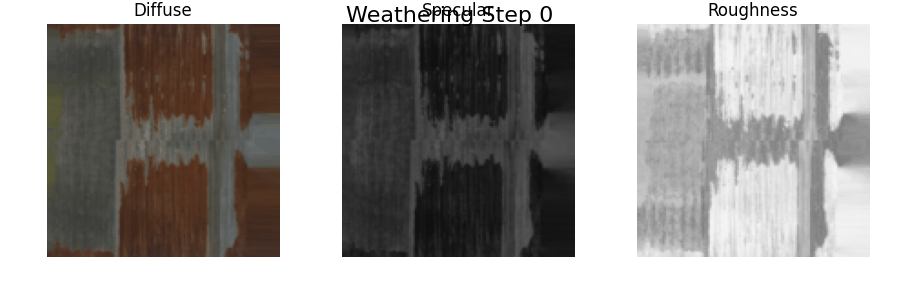

In [ ]:
#steps = build_weathering_sequence_semantic(FX, M, trajectory, W=SAMPLING_SIZE, H=SAMPLING_SIZE, max_step=30)
#visualize_weathering_sequence(steps)

interactive(children=(IntSlider(value=0, description='Step:', max=0), Output()), _dom_classes=('widget-interac…

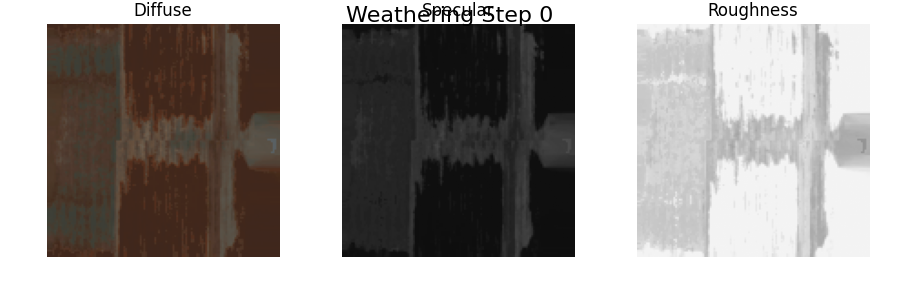

interactive(children=(IntSlider(value=0, description='Step:', max=0), Output()), _dom_classes=('widget-interac…

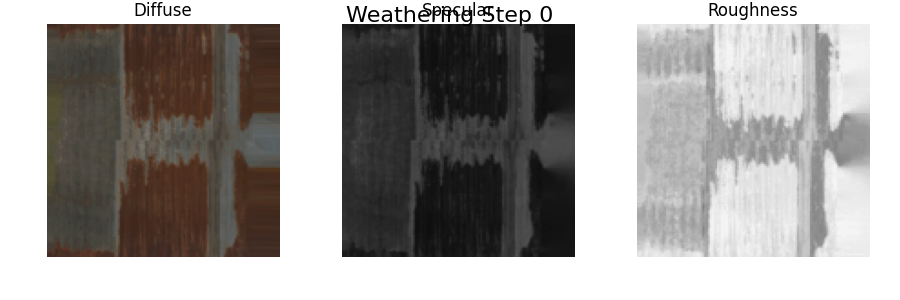

In [20]:
DPath = "C:\\Users\\user\\Desktop\\2026CapstoneDesign_08_01\\Content\\03Python\\AppearanceManifold\\weathering_mid_basecolor.png"
SPath = "C:\\Users\\user\\Desktop\\2026CapstoneDesign_08_01\\Content\\03Python\\AppearanceManifold\\weathering_mid_specular.png"
RPath = "C:\\Users\\user\\Desktop\\2026CapstoneDesign_08_01\\Content\\03Python\\AppearanceManifold\\weathering_mid_roughness.png"
D2,S2,R2 = load_and_downsample(DPath, SPath, RPath, SAMPLING_SIZE)

X2 = combine_to_7d_tensor(D2,S2,R2) # 2차원 이미지 형태
FX2 = combine_to_7d(D2,S2,R2)     

newTex = build_weathering_interpolation_path(X, X2, FX, trajectory_nodes, alpha=0.25)
visualize_weathering_sequence([X2])

visualize_weathering_sequence([newTex])

In [ ]:
#from LoggerClass import evaluate_all_sequence
#evaluate_all_sequence(src, dst, wei, Z, D, M, trajectory, "Texture_Eval")